# Detección de Anomalías Supervisada y No Supervisada - Dataset HIGGS

## Objetivo del Proyecto
Desarrollar una solución analítica para identificar y priorizar eventos anómalos (señales de colisión del Bosón de Higgs) en un dataset altamente desbalanceado (~1% de positividad). Se evaluarán enfoques supervisados, no supervisados e integrados para optimizar la generación de alertas y minimizar falsos positivos.


### 0. Carga de Datos

In [36]:
import pandas as pd
import numpy as np

parte1_path = "data/higgs_anomaly_400k_part1.parquet"
parte2_path = "data/higgs_anomaly_400k_part2.parquet"

df_parte1 = pd.read_parquet(parte1_path)

df_parte2 = pd.read_parquet(parte2_path)

df = pd.concat([df_parte1, df_parte2], ignore_index=True)

print(f"Dimensiones totales del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")


Dimensiones totales del dataset: 400000 filas y 30 columnas.


## 1. Definición de Anomalía y Análisis de los Datos

In [37]:
df.head()

,event_id,lepton_pt,lepton_eta,lepton_phi,missing_energy_magnitude,missing_energy_phi,jet_1_pt,jet_1_eta,jet_1_phi,jet_1_b_tag,...,jet_4_phi,jet_4_b_tag,mass_jj,mass_jjj,mass_lv,mass_jlv,mass_bb,mass_wbb,mass_wwbb,is_signal
0,10564442,1.721567,0.372976,1.026355,0.177679,-1.078458,0.664977,-0.444639,-1.397525,2.173076,...,0.491491,0.0,1.038409,0.982106,0.989194,0.893509,1.281010,0.911054,0.860807,0
1,1420512,0.760769,1.657641,-1.018969,1.047911,1.413517,0.861657,1.148641,-0.510521,0.000000,...,1.141293,0.0,0.924844,0.919754,1.005618,0.807988,0.602472,0.945887,0.895652,0
2,10822309,0.572269,1.124880,-1.610451,1.245221,1.019396,0.773165,0.983273,-1.057693,2.173076,...,-0.356518,0.0,1.045784,1.012153,0.981957,0.626796,0.923795,0.709845,0.698548,0
3,6798554,0.734232,-0.933116,-0.273788,1.704093,1.650188,0.802662,0.029681,1.700984,1.086538,...,0.954287,0.0,0.986455,0.892395,1.529028,1.194787,1.427437,1.001249,0.841272,0
4,8415745,1.894144,-0.290297,0.158552,0.443843,-1.659044,1.868421,0.428744,1.673266,2.173076,...,0.414358,0.0,0.693345,0.666994,1.267468,1.673905,1.811831,1.272984,1.084105,0


### 1.1 Anomalía

El dataset HIGGS proviene de simulaciones de colisiones de partículas de alta energía en el Gran Colisionador de Hadrones (LHC). En estos experimentos, billones de protones chocan a velocidades cercanas a la de la luz para recrear condiciones extremas del universo. 

El objetivo principal es detectar el **Bosón de Higgs**, una partícula elemental que valida el Modelo Estándar de la física pero que tiene un tiempo de vida demasiado corto antes de desintegrarse en otras partículas (como leptones y jets). El reto radica en que los detectores registran una cantidad colosal de eventos ordinarios producto de interacciones físicas comunes y conocidas. Por lo tanto, el descubrimiento de la partícula de interés equivale a buscar una aguja en un pajar de dimensiones astronómicas.

---

#### Definición Formal de la Anomalía en el Dataset
Dentro del marco analítico de este caso de estudio, se establece que **la Anomalía es el evento de Señal (`is_signal = 1`)**, el cual representa la producción y desintegración del Bosón de Higgs. Por el contrario, los eventos de **Background (`is_signal = 0`)** representan el ruido de fondo ordinario. 

Para abordar metodológicamente este problema, separamos su significado en dos dimensiones técnicas:

#### 1.1.1 Definición Operativa
En la física de partículas experimental, las colisiones que generan partículas de interés son fenómenos sumamente raros y difíciles de replicar. La inmensa mayoría de los eventos registrados corresponden a procesos físicos comunes y ya conocidos, agrupados bajo la etiqueta de Background. Al ser la señal el fenómeno de interés científico pero críticamente escaso, el problema se modela bajo el paradigma operativo de detección de anomalías.

#### 1.1.2. Definición Metodológica y Formulación de la Hipótesis
Desde el punto de vista analítico, evaluaremos la anomalía bajo dos enfoques algorítmicos opuestos:

1. **Enfoque Supervisado (Anomalía por Desbalance Extremo):** La anomalía se aborda puramente por su baja frecuencia (~1.00% de probabilidad de ocurrencia). El reto matemático consiste en mitigar el sesgo del clasificador hacia la clase mayoritaria (Background), forzando al algoritmo a identificar patrones multidimensionales sutiles en los datos a pesar de la escasez de ejemplos.
2. **Enfoque No Supervisado (La Anomalía como Outlier de Densidad):** Bajo este marco teórico, una anomalía se define tradicionalmente como un vector cuyas propiedades numéricas se desvían de la distribución central o habitan en regiones de baja densidad estadística. 

> **Hipótesis Central del Proyecto:** *"Que un evento sea operativamente poco frecuente (Señal) no implica que sea estadísticamente atípico (Outlier)."* 
>
> A través del Análisis Exploratorio de Datos (EDA) desafiaremos esta definición tradicional. Evaluaremos si el Bosón de Higgs realmente habita en las colas aisladas de la distribución (lo que permitiría a modelos no supervisados como `Isolation Forest` aislarlo de forma natural) o si, por el contrario, comparte exactamente el mismo espacio geométrico y rango que el ruido de fondo, diferenciándose únicamente en su nivel de concentración. Esta validación geométrica evalua la superioridad de un enfoque sobre el otro.

---

#### Justificación
Clasificar la señal como una "anomalía" se justifica bajo estos criterios:

* **Justificación por Escasez Operativa:** Los datos confirman que de cada 100,000 eventos, únicamente 1,000 corresponden a la señal (~1.00%). Al estar confinada a esta probabilidad analítica, cumple con la condición de escasez severa requerida para el diseño de sistemas de alerta.
* **Justificación Algorítmica (Asimetría del Error):** Si el modelo confunde el ruido con una señal (Falso Positivo), genera una alerta analizable. Pero si el modelo clasifica una señal como ruido (Falsos Negativo), el Bosón de Higgs se "borra" y se pierde el hito científico. Al requerir que el sistema penalice severamente la pérdida de eventos escasos, el problema se aleja de la clasificación tradicional y se convierte en un diseño de detección y priorización de anomalías.


### 1.2 Análisis de la Variable Objetivo y Cuantificación del Desbalance

En esta sección analizamos cuantitativamente la columna `is_signal` para medir el grado de desbalance entre los eventos de Background (0) y Señal (1).

El grado de desbalance determina la estrategia de evaluación del modelo. Si el desbalance es extremo (por ejemplo, menor al 5% para la clase minoritaria), las métricas tradicionales como la precisión global (*Accuracy*) quedan totalmente invalidadas. Este análisis nos dará la base para decidir si requerimos técnicas de remuestreo y guiará la elección de métricas robustas (*Precision-Recall AUC*).


--- CUANTIFICACION DEL DESBALANCE ---
Clase 0 (Background): 396,000 eventos (99.00%)
Clase 1 (Señal):     4,000 eventos (1.00%)
Total de registros:  400,000



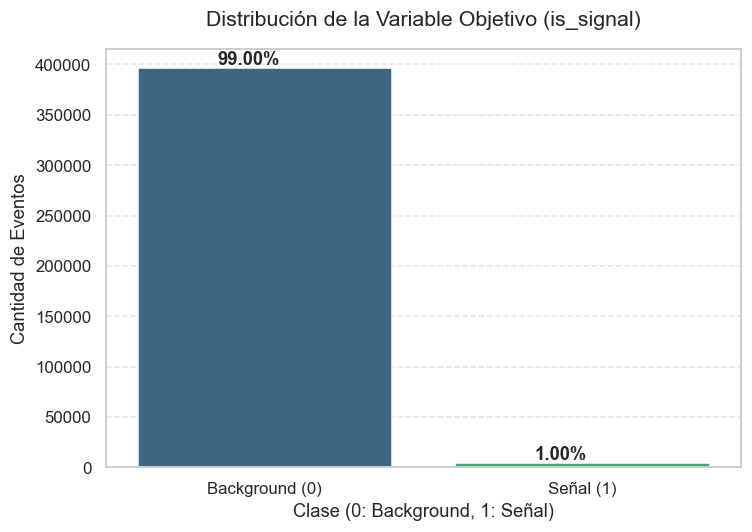

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

conteos = df['is_signal'].value_counts()

porcentajes = df['is_signal'].value_counts(normalize=True) * 100

print("--- CUANTIFICACION DEL DESBALANCE ---")
print(f"Clase 0 (Background): {conteos[0]:,} eventos ({porcentajes[0]:.2f}%)")
print(f"Clase 1 (Señal):     {conteos[1]:,} eventos ({porcentajes[1]:.2f}%)")
print(f"Total de registros:  {df.shape[0]:,}\n")

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='is_signal', data=df, palette='viridis', hue='is_signal', legend=False)

for p in ax.patches:
    percentage = '{:.2f}%'.format(100 * p.get_height() / len(df))
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + (len(df) * 0.01)
    ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold')

plt.title('Distribución de la Variable Objetivo (is_signal)', fontsize=14, pad=15)
plt.xlabel('Clase (0: Background, 1: Señal)', fontsize=12)
plt.ylabel('Cantidad de Eventos', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Background (0)', 'Señal (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Segmentación de Características: Bajo Nivel vs. Alto Nivel

Para diseñar una estrategia analítica efectiva, dividimos las variables predictoras (excluyendo `event_id` e `is_signal`) en dos categorías fundamentales según su procedencia física y matemática.

### Variables de Bajo Nivel
Corresponden a las propiedades física puras medidas directamente por los detectores del colisionador de partículas inmediatamente después del choque. Incluyen:
* **Momentos transversales (`_pt`)**: La energía/movimiento de las partículas en el eje perpendicular a la colisión.
* **Pseudorapidez (`_eta`)** y **Ángulos Azimutales (`_phi`)**: Coordenadas espaciales que identifican la trayectoria exacta de salida de los leptones y jets.
* **Magnitudes de energía faltante (`missing_energy_magnitude`)**: Energía que teóricamente debió registrarse pero "desapareció" (lo que sugiere la presencia de partículas invisibles como neutrinos o materia oscura).

### Variables de Alto Nivel
Son funciones no lineales complejas calculadas posteriormente por los físicos mediante ecuaciones teóricas (como variables de masa invariante: `mass_jj`, `mass_mmbb`, etc.). 

In [39]:
# Verificación de los nombres de las variables
# Imprimir las columnas desde la posición 20 hasta la 30 para ver la frontera real
for i, col in enumerate(df.columns):
    if i >= 20:
        print(f"Índice {i}: {col}")


Índice 20: jet_4_phi
Índice 21: jet_4_b_tag
Índice 22: mass_jj
Índice 23: mass_jjj
Índice 24: mass_lv
Índice 25: mass_jlv
Índice 26: mass_bb
Índice 27: mass_wbb
Índice 28: mass_wwbb
Índice 29: is_signal


In [40]:
columnas_totales = df.columns.tolist()

identificadores = ['event_id']
objetivo = ['is_signal']

features_bajo_nivel = columnas_totales[1:22]

features_alto_nivel = columnas_totales[22:29]

print(f"Variables de Bajo Nivel detectadas: {len(features_bajo_nivel)}")
print(f"Variables de Alto Nivel detectadas: {len(features_alto_nivel)}")
print(f"Otras Variables:       {len(identificadores) + len(objetivo)}")
print(f"Suma total:              {len(features_bajo_nivel) + len(features_alto_nivel) + len(identificadores) + len(objetivo)}")

print("\n Bajo Nivel:", features_bajo_nivel)
print("Alto Nivel:", features_alto_nivel)


Variables de Bajo Nivel detectadas: 21
Variables de Alto Nivel detectadas: 7
Otras Variables:       2
Suma total:              30

 Bajo Nivel: ['lepton_pt', 'lepton_eta', 'lepton_phi', 'missing_energy_magnitude', 'missing_energy_phi', 'jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_b_tag', 'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_b_tag', 'jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_b_tag', 'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_b_tag']
Alto Nivel: ['mass_jj', 'mass_jjj', 'mass_lv', 'mass_jlv', 'mass_bb', 'mass_wbb', 'mass_wwbb']


### 1.3 Señal vs. Background

En esta sección realizamos un análisis estadístico y visual comparativo para identificar si las variables predictoras muestran comportamientos marcadamente distintos cuando el evento es una Señal (1) frente a cuando es Background (0).

Si las medias y las distribuciones de ambos grupos son idénticas, los modelos tendrán serias dificultades para separarlos. Si encontramos variables donde las curvas de densidad no se solapan, habremos descubierto los "puntos clave" que los algoritmos utilizarán para identificar el Bosón de Higgs. Además, esto nos permitirá comprobar si la señal se comporta como un outlier tradicional o no.


In [41]:
df_sin_id = df.drop(columns=['event_id'])
medias_por_clase = df_sin_id.groupby('is_signal').mean().T

medias_por_clase.columns = ['Media_Background_0', 'Media_Señal_1']

medias_por_clase['Diferencia_Absoluta'] = (medias_por_clase['Media_Señal_1'] - medias_por_clase['Media_Background_0']).abs()
medias_por_clase['Cambio_Porcentual (%)'] = (medias_por_clase['Diferencia_Absoluta'] / medias_por_clase['Media_Background_0']) * 100

print("--- VARIABLES CON MAYOR DIFERENCIA DE MEDIAS ---")
medias_por_clase.sort_values(by='Cambio_Porcentual (%)', ascending=False).head(10)


--- VARIABLES CON MAYOR DIFERENCIA DE MEDIAS ---


,Media_Background_0,Media_Señal_1,Diferencia_Absoluta,Cambio_Porcentual (%)
lepton_eta,0.000030,-0.024659,0.024689,82872.171875
jet_3_phi,0.001032,-0.038597,0.039629,3841.093018
jet_2_phi,0.000579,-0.011272,0.011851,2048.159668
jet_4_phi,0.000726,0.002466,0.001740,239.599014
mass_bb,1.057213,0.899446,0.157767,14.922937
jet_2_b_tag,1.052867,0.928585,0.124282,11.804118
missing_energy_magnitude,1.061835,0.942872,0.118963,11.203506
mass_wwbb,1.000019,0.918667,0.081352,8.135055
jet_4_b_tag,0.979147,1.039932,0.060786,6.208048
lepton_pt,1.020650,0.957650,0.063000,6.172535


Al analizar el cambio porcentual, observamos un fenómeno matemático engañoso en variables como `lepton_eta` (82,872%) y `jet_3_phi` (3,841%). 

En física de partículas, los ángulos de salida (`eta` y `phi`) se distribuyen simétricamente alrededor de cero. Por lo tanto, el promedio real de estas variables tanto para la Señal como para el Background es prácticamente **cero** (por ejemplo, `lepton_eta` en Background es `0.000030`). Al calcular un cambio porcentual dividiendo entre un número tan cercano a cero, cualquier pequeña variación matemática (como `-0.024`) genera un porcentaje astronómico. Físicamente, esto no significa que la señal sea drásticamente diferente, sino que ambas clases están centradas en el origen.


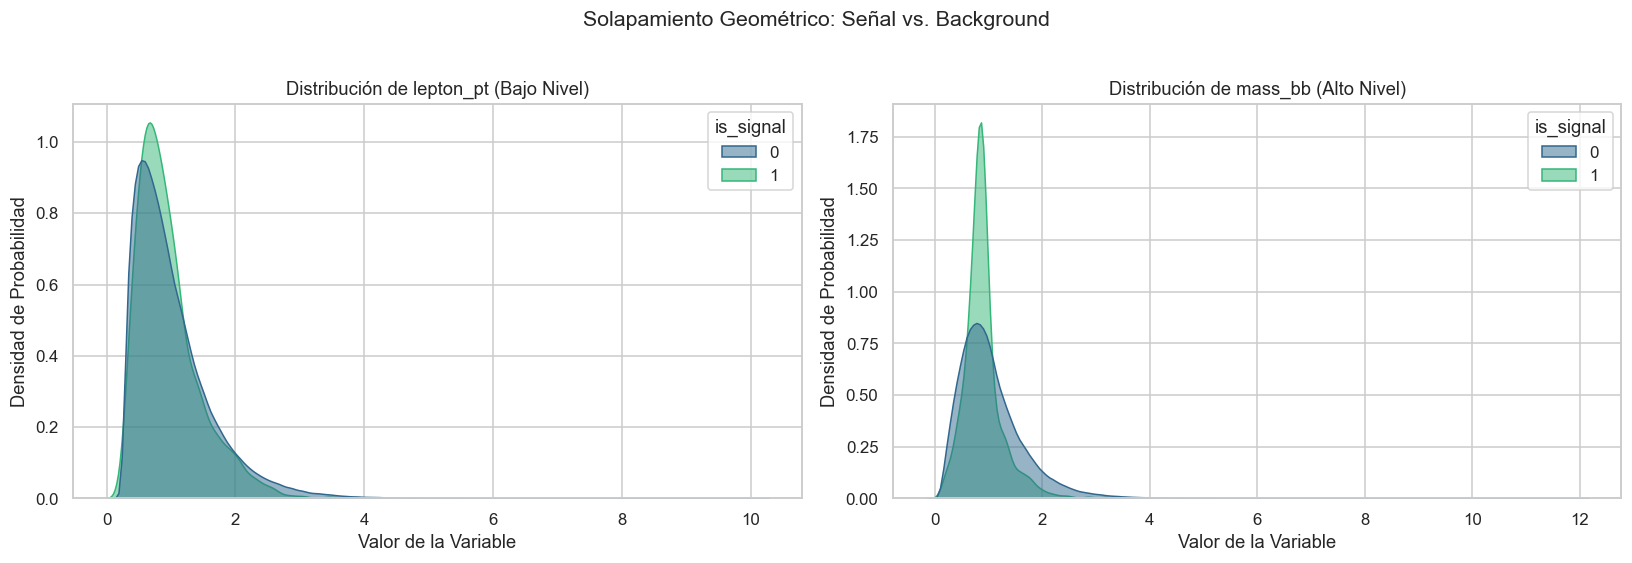

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.kdeplot(data=df, x='lepton_pt', hue='is_signal', fill=True, common_norm=False, palette='viridis', alpha=0.5, ax=axes[0])
axes[0].set_title('Distribución de lepton_pt (Bajo Nivel)', fontsize=12)
axes[0].set_xlabel('Valor de la Variable')
axes[0].set_ylabel('Densidad de Probabilidad')

sns.kdeplot(data=df, x='mass_bb', hue='is_signal', fill=True, common_norm=False, palette='viridis', alpha=0.5, ax=axes[1])
axes[1].set_title('Distribución de mass_bb (Alto Nivel)', fontsize=12)
axes[1].set_xlabel('Valor de la Variable')
axes[1].set_ylabel('Densidad de Probabilidad')

plt.suptitle('Solapamiento Geométrico: Señal vs. Background', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Comportamiento Geométrico de las Distribuciones (Análisis del Solapamiento)**

En la separación se observa en variables físicas de masa y energía:

1. **Bajo Nivel (`lepton_pt`):** Las curvas de densidad para Señal (1) y Background (0) son muy idénticas y están completamente solapadas. Esto demuestra empíricamente que **la Señal NO es un outlier estadístico**; un leptón proveniente del Bosón de Higgs se mueve con impulsos idénticos a los del ruido común.

2. **Alto Nivel (`mass_bb`):** A diferencia de lo que se podría esperar, no existe un desplazamiento horizontal en las distribuciones; ambas clases están centradas en el mismo rango de valores. La única diferencia radica en la **amplitud de la densidad (eje Y)**: el Señal (1) presenta un pico de concentración significativamente más alto y agudo, mientras que la Background (0) mantiene una base y forma idénticas pero con un pico de densidad menor. 

Dado que las distribuciones comparten exactamente el mismo espacio geométrico (mismos centros y colas) y solo difieren en su nivel de concentración, confirmamos que **la Señal se esconde de forma idéntica dentro del ruido**. 

Esto tiene una implicación para el caso de estudio: los algoritmos **No Supervisados** (como *Isolation Forest*), que dependen de encontrar puntos en regiones aisladas o de baja densidad del espacio, van a fracasar casi por completo, ya que la señal esta exactamente en la misma región de alta densidad que el background. Por lo tanto, el enfoque **Supervisado** es ayudará mejor para intentar encontrar patrones o interacciones sutiles entre múltiples variables simultáneamente que permitan romper este solapamiento.

### 1.4 Comparación Bajo Nivel vs. Alto Nivel vs. Conjunto Completo

En esta sección realizamos un Análisis Exploratorio de Datos (EDA) comparativo entre los tres conjuntos de características definidos para el caso de estudio. 

Cada bloque de variables aporta una estructura geométrica distinta al espacio de datos. Comparar sus correlaciones, su dispersión y su nivel de solapamiento matemático nos permitirá diagnosticar, antes de entrenar cualquier modelo, qué tan complejo será el límite de decisión y si la ingeniería de características experta (alto nivel) realmente simplifica la tarea de clasificación frente a los datos de bajo nivel.


#### Análisis de Correlación Promedio


In [43]:
def obtener_correlacion_promedio(df_sub):
    corr = df_sub.corr().abs()
    mask = np.eye(corr.shape[0], dtype=bool)
    return corr.values[~mask].mean()

corr_bajo = obtener_correlacion_promedio(df[features_bajo_nivel])
corr_alto = obtener_correlacion_promedio(df[features_alto_nivel])
corr_completo = obtener_correlacion_promedio(df[features_bajo_nivel + features_alto_nivel])

print(f"Correlación absoluta promedio en Bajo Nivel: {corr_bajo:.4f}")
print(f"Correlación absoluta promedio en Alto Nivel: {corr_alto:.4f}")
print(f"Correlación absoluta promedio en Conjunto Completo: {corr_completo:.4f}\n")


Correlación absoluta promedio en Bajo Nivel: 0.0448
Correlación absoluta promedio en Alto Nivel: 0.3236
Correlación absoluta promedio en Conjunto Completo: 0.0718



El contraste cuantitativo de la correlación absoluta promedio entre los tres bloques de variables nos muestra la naturaleza estructural del dataset:

* **Bajo Nivel (0.0448):** Confirma una independencia casi estadística entre las mediciones físicas en bruto. Esto refleja la naturaleza del detector, donde variables cinemáticas y espaciales independientes (momentos, ángulos) no se condicionan linealmente entre sí. Metodológicamente, esto implica que el patrón de la Señal está disperso en interacciones multivariadas complejas que requieren algoritmos no lineales para ser extraídas.
* **Alto Nivel (0.3236):** Exhibe una conectividad significativamente superior debido a la redundancia matemática. Al ser masas invariantes calculadas mediante la combinación de las variables de bajo nivel, comparten componentes físicos comunes en sus ecuaciones, lo que eleva su correlación. Esto demuestra que el bloque de alto nivel actúa como un espacio de información pre-sintetizada y guiada por el conocimiento del dominio.
* **Conjunto Completo (0.0718):** El promedio global se diluye debido a la dominancia numérica de las 21 variables de bajo nivel sobre las 7 de alto nivel. 

Los modelos basados en árboles de decisión se beneficiarán enormemente de la coexistencia de ambos: utilizarán las variables de alto nivel como "atajos predictivos" gracias a su síntesis matemática, mientras usan las de bajo nivel para afinar la frontera de decisión con los datos puros en bruto.


#### Poder De Separación (MEDIANAS DE SCORE F)

In [44]:
from sklearn.feature_selection import f_classif

f_scores_bajo, _ = f_classif(df[features_bajo_nivel], df['is_signal'])
f_scores_alto, _ = f_classif(df[features_alto_nivel], df['is_signal'])
f_scores_completo, _ = f_classif(df[features_bajo_nivel + features_alto_nivel], df['is_signal'])

print("--- PODER DE SEPARACIÓN DISCRIMINANTE (MEDIANAS DE SCORE F) ---")
print(f"Capacidad de separación mediana - Bajo Nivel: {np.median(f_scores_bajo):.2f}")
print(f"Capacidad de separación mediana - Alto Nivel: {np.median(f_scores_alto):.2f}")
print(f"Capacidad de separación mediana - Conjunto Completo: {np.median(f_scores_completo):.2f}")


--- PODER DE SEPARACIÓN DISCRIMINANTE (MEDIANAS DE SCORE F) ---
Capacidad de separación mediana - Bajo Nivel: 2.31
Capacidad de separación mediana - Alto Nivel: 19.47
Capacidad de separación mediana - Conjunto Completo: 4.40


El análisis de la capacidad discriminante mediante las medianas del Score F revela el impacto de la ingeniería de características en el dataset:

* **Bajo Nivel (2.31):** Registra el valor más bajo. Confirma matemáticamente el solapamiento extremo observado en los gráficos de densidad. De forma individual, las mediciones de los detectores no tienen la fuerza estadística para separar la señal del ruido.
* **Alto Nivel (19.47):** Presenta un incremento en el poder de separación. Las masas calculadas mitigan el ruido y clarifican la frontera entre los grupos, facilitando la tarea de clasificación.
* **Conjunto Completo (4.40):** El poder discriminante mediano se diluye debido a la superioridad numérica de las variables de bajo nivel (21 columnas débiles frente a 7 fuertes).

**Implicación para el Caso de Estudio:** Este resultado predice que un modelo entrenado únicamente con variables de Alto Nivel podría ser sumamente eficiente y rápido. Sin embargo, para maximizar la detección en el Conjunto Completo, se requerirán modelos robustos basados en árboles capaces de seleccionar automáticamente las características con mayor Score F e ignorar las que añaden ruido matemático.


#### Gráfico de Dispersión 

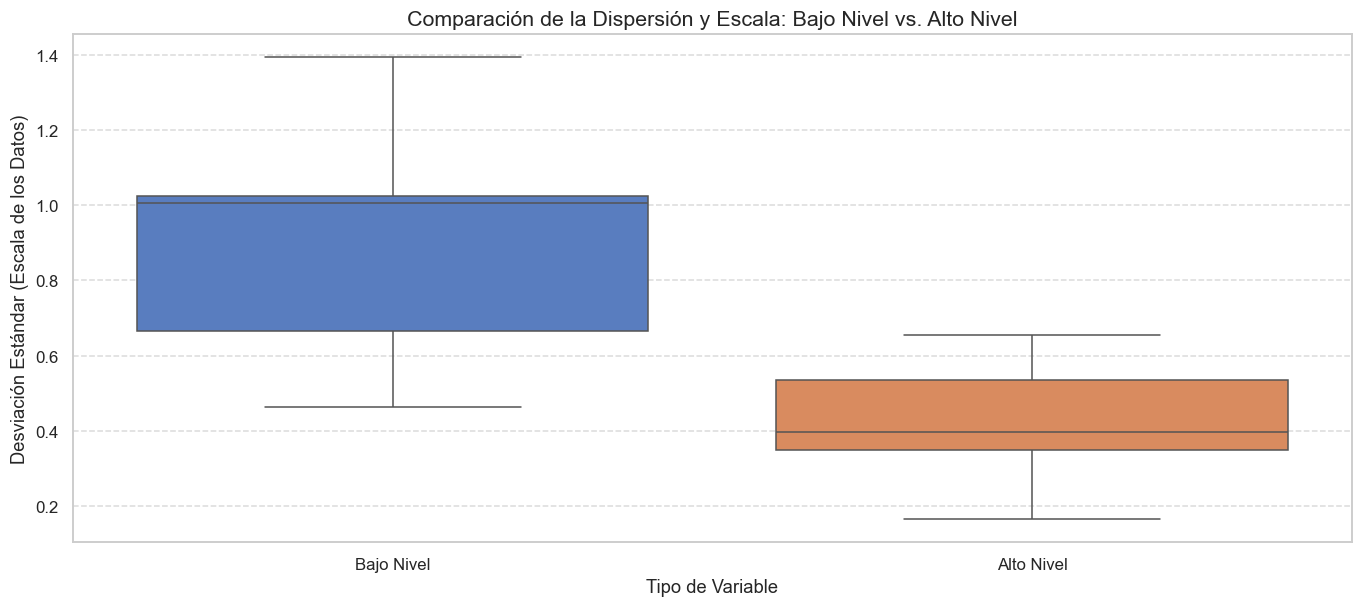

In [45]:
plt.figure(figsize=(15, 6))

desviaciones = pd.DataFrame({
    'Desviación Estándar': df[features_bajo_nivel + features_alto_nivel].std(),
    'Tipo de Variable': ['Bajo Nivel']*len(features_bajo_nivel) + ['Alto Nivel']*len(features_alto_nivel)
})

sns.boxplot(data=desviaciones, x='Tipo de Variable', y='Desviación Estándar', palette='muted', hue='Tipo de Variable', legend=False)
plt.title('Comparación de la Dispersión y Escala: Bajo Nivel vs. Alto Nivel', fontsize=14)
plt.ylabel('Desviación Estándar (Escala de los Datos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


El análisis de las desviaciones estándar revela un comportamiento opuesto en la distribución de las escalas de ambos bloques:

* **Bajo Nivel:** Presenta una alta dispersión debido a la naturaleza caótica de las colisiones en bruto, donde la energía y los ángulos varían drásticamente en cada evento registrado por los detectores.
* **Alto Nivel:** Muestra una dispersión significativamente menor y compacta. Esto ocurre porque las fórmulas matemáticas calculan masas de partículas específicas; por leyes físicas, estas masas tienden a concentrarse en rangos fijos y controlados, reduciendo la variabilidad del ruido.

**Implicación Crítica para Modelos de Distancia:** Debido a que el bloque de bajo nivel tiene variables con el doble de dispersión y escala que el de alto nivel, el uso del **Conjunto Completo** en algoritmos sensibles a distancias se verá sesgado, dándole más peso visual al bajo nivel de forma artificial. Esto justifica la necesidad de aplicar una estandarización de datos (`StandardScaler`) antes de entrenar dichos modelos.


## 2. Enfoque Supervisado

In [46]:
import warnings
from pathlib import Path

import joblib
from matplotlib.patches import Patch

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix,
                             f1_score, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

features_completo = features_bajo_nivel + features_alto_nivel


#### 2.0 Partición estratificada en entrenamiento, validación y prueba

La partición habitual en entrenamiento y prueba resulta
insuficiente, porque el apartado 2.5 exige ajustar el umbral de
decisión utilizando el conjunto de validación. El umbral es un hiperparámetro de operación y se elige
observando métricas. Si se eligiera observando el conjunto de prueba, ese conjunto dejaría de ser una muestra
ciega y las métricas finales quedarían sesgadas al alza.

Por lo tanto, se estratifica la data de la siguiente manera,

- Entrenamiento 60%, Ajustar los parámetros de los modelos y aplicar el remuestreo.
- Validación 20%, Seleccionar el modelo y calibrar el umbral de decisión.
- Prueba 20%, Estimar el desempeño final una única vez, sin retroalimentación.

Se elige así, ya que con una prevalencia del 1 %, una partición aleatoria simple
podría repartir los positivos de forma desigual por puro azar. La estratificación fuerza a que
las tres particiones conserven la misma proporción de señales, garantizando que las métricas sean comparables
entre conjuntos. Con 4000 señales disponibles, la partición produce aproximadamente 2400 / 800 / 800
positivos.

In [47]:
X = df[features_completo].copy()
y = df[objetivo[0]].to_numpy()
ids = df[identificadores[0]].to_numpy()

# Primer corte: se aparta el 20 % como conjunto de prueba definitivo.
X_temp, X_test, y_temp, y_test, id_temp, id_test = train_test_split(
    X, y, ids, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# Segundo corte: del 80 % se toma el 20 % del total.
X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
    X_temp, y_temp, id_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)

resumen_particion = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validacion", "Prueba"],
    "Eventos": [len(y_train), len(y_val), len(y_test)],
    "Senales": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
})
resumen_particion["Background"] = resumen_particion["Eventos"] - resumen_particion["Senales"]
resumen_particion["% del total"] = (100 * resumen_particion["Eventos"] / len(y)).round(2)
resumen_particion["Prevalencia (%)"] = (
    100 * resumen_particion["Senales"] / resumen_particion["Eventos"]).round(4)

display(resumen_particion)


,Conjunto,Eventos,Senales,Background,% del total,Prevalencia (%)
0,Entrenamiento,240000,2400,237600,60.0,1.0
1,Validacion,80000,800,79200,20.0,1.0
2,Prueba,80000,800,79200,20.0,1.0


#### 2.0.1 Estandarización 

El análisis de dispersión de la Sección 1 concluyó que las variables de bajo nivel presentan aproximadamente
el doble de desviación estándar que las de alto nivel, y que ello justifica aplicar StandardScaler antes
de usar modelos sensibles a la escala. 

La media y la desviación estándar son parámetros que se aprenden de los datos. Si se calcularan sobre el dataset completo, los conjuntos de
validación y prueba habrían influido en la transformación y existiría fuga de información
La estandarización se aplica a la Regresión Logística por dos motivos,

1. Convergencia numérica, El optimizador converge de forma más estable cuando todas las variables
   comparten escala.
2. Comparabilidad de coeficientes, Solo con predictores estandarizados la magnitud de un coeficiente
   refleja la importancia relativa de la variable.

In [48]:
escalador = StandardScaler().fit(X_train)   # Ajuste en entrenamiento

X_train_esc = escalador.transform(X_train)
X_val_esc   = escalador.transform(X_val)
X_test_esc  = escalador.transform(X_test)

verificacion = pd.DataFrame({
    "Media (train escalado)": X_train_esc.mean(axis=0),
    "Desv. (train escalado)": X_train_esc.std(axis=0),
    "Media (val escalado)":   X_val_esc.mean(axis=0),
    "Media (test escalado)":  X_test_esc.mean(axis=0),
}, index=features_completo)


print("El entrenamiento queda centrado exactamente en 0 con desviacion 1.")
print("Validacion y prueba quedan CERCA de 0, pero no exactamente, no participaron en el ajuste.\n")
display(verificacion.head(6).round(6))

El entrenamiento queda centrado exactamente en 0 con desviacion 1.
Validacion y prueba quedan CERCA de 0, pero no exactamente, no participaron en el ajuste.



,Media (train escalado),Desv. (train escalado),Media (val escalado),Media (test escalado)
lepton_pt,-0.0,1.0,-0.006048,0.001742
lepton_eta,0.0,1.0,0.006015,0.003561
lepton_phi,-0.0,1.0,0.003136,-0.000480
missing_energy_magnitude,0.0,1.0,-0.000757,-0.002472
missing_energy_phi,0.0,1.0,-0.000264,0.002012
jet_1_pt,0.0,1.0,-0.002029,-0.006185


Funciones reutilizables

In [49]:
def evaluar_umbral(y_true, y_score, umbral, nombre=""):
    """Calcula el conjunto completo de metricas para un umbral de decision dado."""
    y_pred = (y_score >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "Modelo": nombre,
        "Umbral": float(umbral),
        "AP": average_precision_score(y_true, y_score),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Alertas": int(y_pred.sum()),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
    }


def umbral_maximo_f1(y_true, y_score):
    """Devuelve el umbral que maximiza F1. Debe invocarse SOLO sobre validacion."""
    precision, recall, umbrales = precision_recall_curve(y_true, y_score)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    return float(umbrales[int(np.nanargmax(f1[:-1]))])


def umbral_por_presupuesto(y_score, n_alertas):
    """Devuelve el umbral que produce exactamente n_alertas eventos priorizados."""
    return float(np.sort(y_score)[::-1][n_alertas - 1])


def metricas_top_k(y_true, y_score, k):
    """Evalua unicamente los k eventos de mayor prioridad (vision operativa)."""
    orden = np.argsort(y_score)[::-1][:k]
    tp = int(np.asarray(y_true)[orden].sum())
    total_positivos = int(np.asarray(y_true).sum())
    return {"k": k, "TP@k": tp, "Precision@k": tp / k,
            "Recall@k": tp / total_positivos,
            "Lift@k": (tp / k) / np.asarray(y_true).mean()}


def graficar_matriz_confusion(y_true, y_score, umbral, titulo, ax=None):
    """Dibuja la matriz de confusion correspondiente a un umbral dado."""
    y_pred = (y_score >= umbral).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3.4))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="viridis", cbar=False,
                xticklabels=["Background", "Senal"],
                yticklabels=["Background", "Senal"], ax=ax)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Valor real"); ax.set_title(titulo, fontsize=10)
    return ax


# Presupuesto operativo de alertas: 1 % del conjunto evaluado.
PRESUPUESTO_TEST = int(round(0.01 * len(y_test)))
PRESUPUESTO_VAL  = int(round(0.01 * len(y_val)))

print("Funciones de evaluacion definidas.")
print(f"Presupuesto de alertas en validacion : {PRESUPUESTO_VAL:,} eventos")
print(f"Presupuesto de alertas en prueba     : {PRESUPUESTO_TEST:,} eventos")

Funciones de evaluacion definidas.
Presupuesto de alertas en validacion : 800 eventos
Presupuesto de alertas en prueba     : 800 eventos


### 2.1 Regresión Logística como modelo base

#### 2.1.1 Fundamento y papel dentro del estudio

La Regresión Logística modela la probabilidad de que un evento sea señal mediante una combinación lineal de
los predictores transformada por la función sigmoide.

Su valor en este trabajo es el siguiente,

1. Referencia mínima de desempeño, Establece el resultado alcanzable con una frontera de decisión
   lineal.
2. Contraste directo con la hipótesis de la Sección 1. el análisis concluyó que el patrón de la
   señal reside en interacciones multivariadas. Si esa conclusión es correcta, un modelo estrictamente
   lineal, incapaz de representar interacciones, debe quedar claramente por debajo del modelo de árboles
   del apartado 2.2.

In [50]:
logreg_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg_base.fit(X_train_esc, y_train)

prob_val_lr_base  = logreg_base.predict_proba(X_val_esc)[:, 1]
prob_test_lr_base = logreg_base.predict_proba(X_test_esc)[:, 1]

ap_val = average_precision_score(y_val, prob_val_lr_base)

print(f"Iteraciones hasta convergencia : {logreg_base.n_iter_[0]}")
print(f"AP en validacion               : {ap_val:.4f}")
print(f"AP en prueba                   : {average_precision_score(y_test, prob_test_lr_base):.4f}")
print(f"ROC-AUC en prueba              : {roc_auc_score(y_test, prob_test_lr_base):.4f}")
print(f"\nMejora del AP sobre el azar     : x{ap_val/y_val.mean():.2f}")

Iteraciones hasta convergencia : 19
AP en validacion               : 0.0238
AP en prueba                   : 0.0253
ROC-AUC en prueba              : 0.6968

Mejora del AP sobre el azar     : x2.38


#### 2.1.2 El problema del umbral 0.5

Por convención, predict() clasifica como positivo todo evento con probabilidad estimada superior a 0.5.
Ese valor asume que ambas clases son igual de frecuentes. Con una prevalencia del 1 %, el modelo aprende que la respuesta "background" es correcta el 99 % de las
veces. Sus probabilidades estimadas se concentran, por tanto, en valores muy bajos y prácticamente
ningún evento supera el 0.5.

Alertas generadas      : 1
Verdaderos positivos   : 0 de 800 senales
Recall                 : 0.0000
F1                     : 0.0000

Probabilidad maxima asignada por el modelo : 0.5174
Percentil 99 de las probabilidades         : 0.0359
Eventos con probabilidad > 0.5             : 1


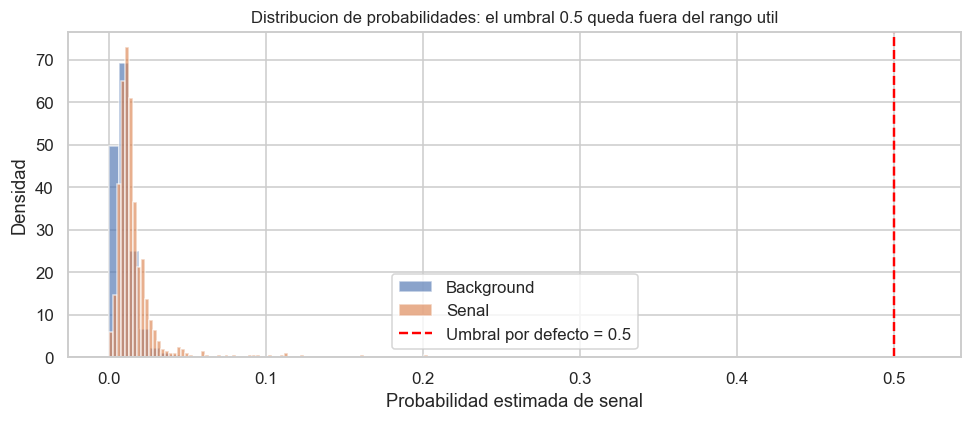

In [51]:
res_lr_05 = evaluar_umbral(y_test, prob_test_lr_base, 0.5, "LogReg base @ umbral 0.5")

print(f"Alertas generadas      : {res_lr_05['Alertas']:,}")
print(f"Verdaderos positivos   : {res_lr_05['TP']} de {int(y_test.sum())} senales")
print(f"Recall                 : {res_lr_05['Recall']:.4f}")
print(f"F1                     : {res_lr_05['F1']:.4f}")

print(f"\nProbabilidad maxima asignada por el modelo : {prob_test_lr_base.max():.4f}")
print(f"Percentil 99 de las probabilidades         : {np.percentile(prob_test_lr_base, 99):.4f}")
print(f"Eventos con probabilidad > 0.5             : {(prob_test_lr_base > 0.5).sum():,}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(prob_test_lr_base[y_test == 0], bins=80, alpha=0.65, label="Background", density=True)
ax.hist(prob_test_lr_base[y_test == 1], bins=80, alpha=0.65, label="Senal", density=True)
ax.axvline(0.5, color="red", ls="--", lw=1.6, label="Umbral por defecto = 0.5")
ax.set_xlabel("Probabilidad estimada de senal")
ax.set_ylabel("Densidad")
ax.set_title("Distribucion de probabilidades: el umbral 0.5 queda fuera del rango util", fontsize=11)
ax.legend()
plt.tight_layout(); plt.show()

El histograma muestra que la totalidad de la masa probabilística se acumula muy
por debajo de 0.5. El umbral por defecto queda fuera del rango de valores que el modelo produce, exhibe un
accuracy excelente y un recall nulo o casi nulo.

Se observa, además, que las distribuciones de ambas clases se cruzan pero no coinciden, la de señal
está desplazada hacia la derecha. Existe señal aprovechable en el ordenamiento, lo que falla es el punto de
corte.

#### 2.1.3 Interpretación de los coeficientes

Al estar los predictores estandarizados, la magnitud de cada coeficiente es directamente comparable e
indica cuánto altera el log-odds de señal un incremento de una desviación estándar en esa variable.

,Coeficiente,Magnitud,Bloque
mass_wwbb,-1.2991,1.2991,Alto nivel
mass_wbb,0.7549,0.7549,Alto nivel
mass_bb,-0.5902,0.5902,Alto nivel
jet_1_pt,0.3836,0.3836,Bajo nivel
mass_jjj,0.2693,0.2693,Alto nivel
missing_energy_magnitude,-0.1821,0.1821,Bajo nivel
mass_jlv,0.1682,0.1682,Alto nivel
lepton_pt,-0.1676,0.1676,Bajo nivel
jet_4_pt,0.1430,0.1430,Bajo nivel
mass_jj,-0.1297,0.1297,Alto nivel


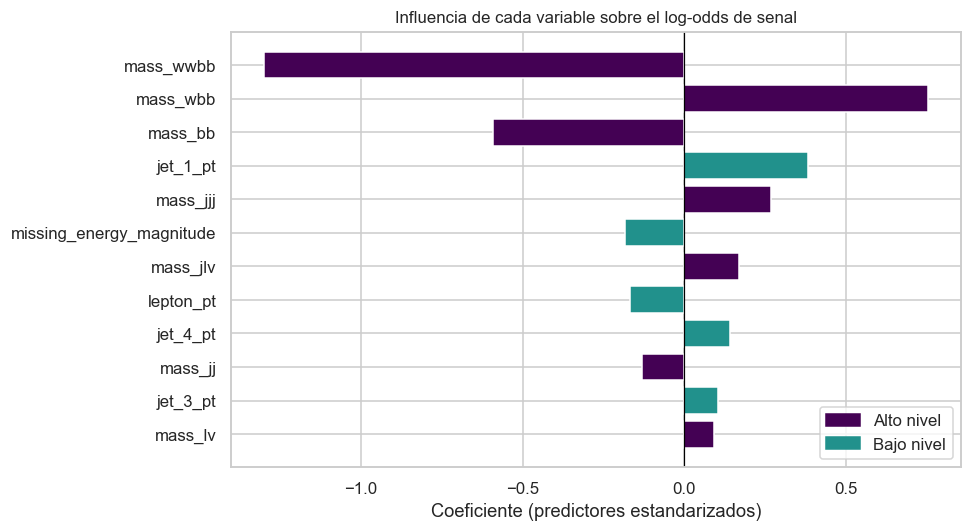

Variables de alto nivel dentro del top 10: 6 de 10
(el bloque de alto nivel representa solo 7/28 del espacio total)


In [52]:
coeficientes = pd.Series(logreg_base.coef_[0], index=features_completo)
coef_ordenados = coeficientes.reindex(coeficientes.abs().sort_values(ascending=False).index)

tabla_coef = pd.DataFrame({
    "Coeficiente": coef_ordenados,
    "Magnitud": coef_ordenados.abs(),
    "Bloque": ["Alto nivel" if v in features_alto_nivel else "Bajo nivel" for v in coef_ordenados.index],
})

display(tabla_coef.head(12).round(4))

top12 = coef_ordenados.head(12).iloc[::-1]
colores = ["#440154" if v in features_alto_nivel else "#21918c" for v in top12.index]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top12.index, top12.values, color=colores)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Coeficiente (predictores estandarizados)")
ax.set_title("Influencia de cada variable sobre el log-odds de senal", fontsize=11)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#440154", label="Alto nivel"),
                   Patch(color="#21918c", label="Bajo nivel")], loc="lower right")
plt.tight_layout(); plt.show()

n_alto_top10 = sum(1 for v in coef_ordenados.head(10).index if v in features_alto_nivel)
print(f"Variables de alto nivel dentro del top 10: {n_alto_top10} de 10")
print(f"(el bloque de alto nivel representa solo {len(features_alto_nivel)}/{len(features_completo)} del espacio total)")

Las variables de alto nivel están sobrerrepresentadas en el grupo de
mayor influencia respecto a su peso numérico en el espacio de características. Esto corrobora el hallazgo
del F-score de la Sección 1. Las masas invariantes
calculadas por los físicos concentran el poder discriminante, mientras que las mediciones en bruto aportan
poca información de forma individual y lineal.

### 2.2 Segundo modelo de scikit-learn: HistGradientBoostingClassifier

#### 2.2.1 Justificación de la elección

La elección de
HistGradientBoostingClassifier responde a tres criterios explícitos,

1. Coherencia con el diagnóstico de la Sección 1. El análisis concluyó que el patrón de la señal
   reside en interacciones multivariadas complejas y que los modelos de árboles aprovecharían la
   coexistencia de ambos bloques usando las variables de alto nivel como atajos predictivos. 
2. Capacidad de representación. El boosting construye árboles de forma secuencial, y cada árbol nuevo
   se especializa en corregir los errores del conjunto previo. Los árboles capturan interacciones y
   umbrales no lineales que la frontera lineal del modelo base no puede representar.
3. Viabilidad computacional. La variante histogram-based discretiza cada predictor en 256 grupos, lo
   que reduce drásticamente el costo de evaluar cortes candidatos y permite entrenar sobre 240000
   observaciones de forma eficaz.

In [53]:
hgb_base = HistGradientBoostingClassifier(
    max_iter=400,              # numero de arboles del ensamble
    learning_rate=0.08,        # contribucion de cada arbol, valores bajos exigen mas arboles
    max_leaf_nodes=31,         # complejidad maxima por arbol
    l2_regularization=1.0,     # penalizacion que limita el sobreajuste
    early_stopping=False,     
    random_state=RANDOM_STATE,
)
hgb_base.fit(X_train, y_train)  

prob_val_hgb_base  = hgb_base.predict_proba(X_val)[:, 1]
prob_test_hgb_base = hgb_base.predict_proba(X_test)[:, 1]

ap_val_hgb = average_precision_score(y_val, prob_val_hgb_base)
ap_val_lr  = average_precision_score(y_val, prob_val_lr_base)


print(f"AP  Regresion Logistica  : {ap_val_lr:.4f}")
print(f"AP  HistGradientBoosting : {ap_val_hgb:.4f}")
print(f"Mejora relativa          : {100*(ap_val_hgb-ap_val_lr)/ap_val_lr:+.1f}%")
print(f"\nAP del modelo de arboles sobre el azar: x{ap_val_hgb/y_val.mean():.2f}")

AP  Regresion Logistica  : 0.0238
AP  HistGradientBoosting : 0.0795
Mejora relativa          : +233.7%

AP del modelo de arboles sobre el azar: x7.95


Interpretación. La mejora sustancial del modelo de árboles sobre el modelo lineal constituye la
confirmación experimental de la hipótesis de la Sección 1. La información discriminante no reside en
efectos lineales aislados, sino en combinaciones e interacciones entre variables que solo un modelo no
lineal puede explotar.

#### 2.2.2 Validación cruzada: verificación de la estabilidad

Una única medición podría deberse a una partición afortunada. Se emplea StratifiedKFold con 5 pliegues
sobre el conjunto de entrenamiento para estimar la variabilidad del AP. 

In [54]:
cv_estratificada = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelo_cv = HistGradientBoostingClassifier(
    max_iter=200, learning_rate=0.08, max_leaf_nodes=31,
    l2_regularization=1.0, early_stopping=False, random_state=RANDOM_STATE)

ap_pliegues = cross_val_score(modelo_cv, X_train, y_train,
                              cv=cv_estratificada, scoring="average_precision", n_jobs=1)

for i, valor in enumerate(ap_pliegues, start=1):
    print(f"  Pliegue {i}: AP = {valor:.4f}")
print(f"\nAP promedio          : {ap_pliegues.mean():.4f}")
print(f"Desviacion estandar  : {ap_pliegues.std():.4f}")
print(f"Coef. de variacion   : {100*ap_pliegues.std()/ap_pliegues.mean():.1f}%")
print("\nUna desviacion baja indica que el desempeño no depende de la particion concreta.")

  Pliegue 1: AP = 0.0704
  Pliegue 2: AP = 0.0735
  Pliegue 3: AP = 0.0720
  Pliegue 4: AP = 0.0640
  Pliegue 5: AP = 0.0683

AP promedio          : 0.0696
Desviacion estandar  : 0.0033
Coef. de variacion   : 4.7%

Una desviacion baja indica que el desempeño no depende de la particion concreta.


#### 2.2.3 Importancia de características por permutación

El boosting por histogramas no expone coeficientes interpretables. Se recurre a la importancia por
permutación, se altera aleatoriamente una variable y se mide cuánto se degrada el AP. Si la degradación es
grande, el modelo dependía de esa variable.

,Importancia,Desv. estandar,Bloque
mass_wwbb,0.04387,0.00566,Alto nivel
mass_wbb,0.04307,0.00225,Alto nivel
mass_bb,0.04264,0.00224,Alto nivel
jet_1_pt,0.03423,0.00601,Bajo nivel
mass_jjj,0.01533,0.01006,Alto nivel
mass_jlv,0.01517,0.00447,Alto nivel
missing_energy_magnitude,0.01285,0.00502,Bajo nivel
jet_2_pt,0.00798,0.00191,Bajo nivel
mass_jj,0.00781,0.00208,Alto nivel
jet_3_pt,0.00722,0.00224,Bajo nivel


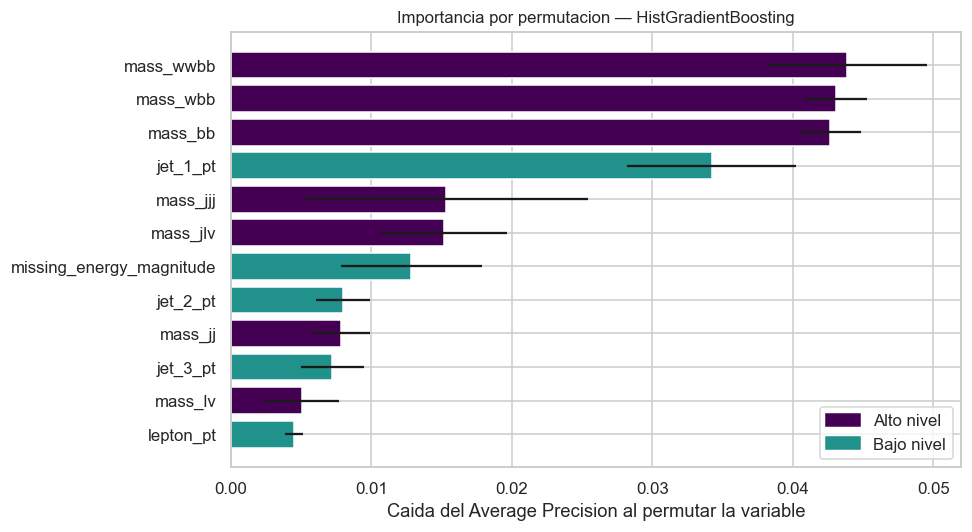

Importancia agregada del bloque de ALTO nivel (7 vars) : 69.5%
Importancia agregada del bloque de BAJO nivel (21 vars): 30.5%


In [55]:
generador = np.random.RandomState(RANDOM_STATE)
idx_muestra = generador.choice(len(X_val), size=15000, replace=False)

importancias = permutation_importance(
    hgb_base, X_val.iloc[idx_muestra], y_val[idx_muestra],
    scoring="average_precision", n_repeats=3,
    random_state=RANDOM_STATE, n_jobs=-1)

tabla_imp = pd.DataFrame({
    "Importancia": importancias.importances_mean,
    "Desv. estandar": importancias.importances_std,
    "Bloque": ["Alto nivel" if v in features_alto_nivel else "Bajo nivel" for v in features_completo],
}, index=features_completo).sort_values("Importancia", ascending=False)

display(tabla_imp.head(12).round(5))

top_imp = tabla_imp.head(12).iloc[::-1]
colores = ["#440154" if b == "Alto nivel" else "#21918c" for b in top_imp["Bloque"]]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_imp.index, top_imp["Importancia"], xerr=top_imp["Desv. estandar"], color=colores)
ax.set_xlabel("Caida del Average Precision al permutar la variable")
ax.set_title("Importancia por permutacion — HistGradientBoosting", fontsize=11)
ax.legend(handles=[Patch(color="#440154", label="Alto nivel"),
                   Patch(color="#21918c", label="Bajo nivel")], loc="lower right")
plt.tight_layout(); plt.show()

peso_alto = tabla_imp.loc[features_alto_nivel, "Importancia"].clip(lower=0).sum()
peso_bajo = tabla_imp.loc[features_bajo_nivel, "Importancia"].clip(lower=0).sum()
total = peso_alto + peso_bajo
print(f"Importancia agregada del bloque de ALTO nivel (7 vars) : {100*peso_alto/total:.1f}%")
print(f"Importancia agregada del bloque de BAJO nivel (21 vars): {100*peso_bajo/total:.1f}%")

#### 2.2.4 Comparación entre representaciones de los datos

El apartado 1.4 predijo, a partir del F-score mediano, que el bloque de alto nivel sería más eficiente y
que el conjunto completo requeriría modelos de árboles para aprovechar ambos bloques. Esta celda verifica
esa predicción con modelos reales, midiendo el AP en validación para cada combinación de representación y
algoritmo.

,N variables,AP LogReg,AP HGB
Representacion,,,
Bajo nivel (21),21,0.0165,0.0219
Alto nivel (7),7,0.0161,0.0719
Completo (28),28,0.0238,0.0809


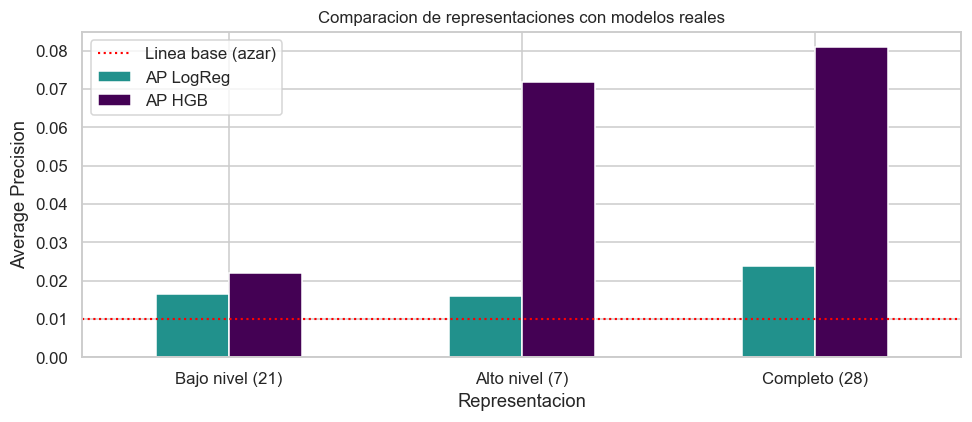

In [56]:
representaciones = {
    "Bajo nivel (21)": features_bajo_nivel,
    "Alto nivel (7)":  features_alto_nivel,
    "Completo (28)":   features_completo,
}

filas_repr = []
for nombre, variables in representaciones.items():
    escalador_local = StandardScaler().fit(X_train[variables])
    lr_local = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr_local.fit(escalador_local.transform(X_train[variables]), y_train)
    ap_lr_local = average_precision_score(
        y_val, lr_local.predict_proba(escalador_local.transform(X_val[variables]))[:, 1])

    hgb_local = HistGradientBoostingClassifier(
        max_iter=200, learning_rate=0.08, max_leaf_nodes=31,
        l2_regularization=1.0, early_stopping=False, random_state=RANDOM_STATE)
    hgb_local.fit(X_train[variables], y_train)
    ap_hgb_local = average_precision_score(y_val, hgb_local.predict_proba(X_val[variables])[:, 1])

    filas_repr.append({"Representacion": nombre, "N variables": len(variables),
                       "AP LogReg": ap_lr_local, "AP HGB": ap_hgb_local})

tabla_repr = pd.DataFrame(filas_repr).set_index("Representacion")
display(tabla_repr.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
tabla_repr[["AP LogReg", "AP HGB"]].plot(kind="bar", ax=ax, rot=0, color=["#21918c", "#440154"])
ax.axhline(y_val.mean(), color="red", ls=":", lw=1.4, label="Linea base (azar)")
ax.set_ylabel("Average Precision")
ax.set_title("Comparacion de representaciones con modelos reales", fontsize=11)
ax.legend()
plt.tight_layout(); plt.show()

El F-score mediano sugería que el conjunto completo
diluía el poder discriminante frente al bloque de alto nivel. La verificación con modelos matiza esa
lectura. El F-score mide el poder individual y univariado de cada variable, mientras que un modelo
multivariado puede combinar variables individualmente débiles. Por eso el conjunto completo no resulta
inferior a pesar de contener 21 variables de bajo F-score, y el modelo de árboles es el que mejor
capitaliza esa combinación.

### 2.3 Comparación del modelo original con estrategias de tratamiento del desbalance

El enunciado exige comparar el modelo original con al menos dos estrategias. Se implementan tres,
elegidas porque intervienen en mecanismos distintos del proceso de aprendizaje,

| Estrategia | Mecanismo de acción | Efecto sobre los datos |
|---|---|---|
| Pesos de clase | Modifica la función de pérdida: cada error sobre una señal pesa ~99 veces más | Ninguno: los datos permanecen intactos |
| Random Undersampling | Elimina observaciones de la clase mayoritaria | Reduce drásticamente el volumen de entrenamiento |
| SMOTE | Genera positivos sintéticos interpolando entre vecinos cercanos reales | Aumenta el volumen con datos artificiales |

#### 2.3.1 Justificación de la proporción de remuestreo

Tanto RandomUnderSampler como SMOTE aceptan el parámetro sampling_strategy. Su valor por defecto
('auto') produce un balance perfecto 1:1, opción que se descarta deliberadamente,

- Con undersampling al 1:1 el entrenamiento se reduciría de 240 000 a unas 4 800 observaciones,
  descartando más del 98 % de la información disponible sobre el background. Dado que el hallazgo de
  la Sección 1 es que ambas clases se solapan, caracterizar bien el background resulta esencial.
- Con SMOTE al 1:1 se generarían ~237 000 positivos sintéticos a partir de solo 2400 reales, es decir, unas
  99 copias interpoladas por cada señal auténtica. El modelo aprendería la geometría del interpolador
  más que la física de la señal.

Se adopta sampling_strategy=0.1. Esto eleva la
prevalencia efectiva del 1 % al ~9 %, suficiente para alterar el punto de operación, sin los efectos
adversos del balanceo total.

#### 2.3.2 Diseño experimental de la comparación

Para que la comparación sea controlada, las cuatro variantes se aplican al mismo algoritmo manteniendo idénticos el resto de los elementos, mismos datos, mismo escalador, mismas métricas y
mismo criterio de umbral. Así, cualquier diferencia observada es atribuible únicamente a la estrategia.

Cada variante se evalúa en dos puntos de operación para separar dos efectos que suelen confundirse,

- Umbral fijo 0.5: revela cómo cada estrategia recalibra las probabilidades del modelo.
- Umbral óptimo de F1 calibrado en validación, revela si la estrategia mejora el desempeño alcanzable
  una vez que el umbral se elige correctamente.

In [ ]:
def entrenar_variante(X_ajuste, y_ajuste, nombre, class_weight=None):
    """Entrena una Regresion Logistica y evalua en dos puntos de operacion."""
    modelo = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                class_weight=class_weight)
    modelo.fit(X_ajuste, y_ajuste)

    prob_val  = modelo.predict_proba(X_val_esc)[:, 1]
    prob_test = modelo.predict_proba(X_test_esc)[:, 1]

    umbral_f1 = umbral_maximo_f1(y_val, prob_val)          # calibrado en validación
    res_05 = evaluar_umbral(y_test, prob_test, 0.5, nombre)
    res_f1 = evaluar_umbral(y_test, prob_test, umbral_f1, nombre)

    return {
        "modelo": modelo, "prob_val": prob_val, "prob_test": prob_test,
        "umbral_f1": umbral_f1, "res_05": res_05, "res_f1": res_f1,
        "n_entrenamiento": len(y_ajuste), "n_positivos": int(np.sum(y_ajuste)),
    }


variantes = {}

variantes["1. Sin tratamiento"] = entrenar_variante(
    X_train_esc, y_train, "LR sin tratamiento")

variantes["2. Pesos de clase"] = entrenar_variante(
    X_train_esc, y_train, "LR pesos de clase", class_weight="balanced")

submuestreador = RandomUnderSampler(sampling_strategy=0.1, random_state=RANDOM_STATE)
X_rus, y_rus = submuestreador.fit_resample(X_train_esc, y_train)
variantes["3. Random Undersampling"] = entrenar_variante(X_rus, y_rus, "LR undersampling")

sintetizador = SMOTE(sampling_strategy=0.1, k_neighbors=5, random_state=RANDOM_STATE)
X_smote, y_smote = sintetizador.fit_resample(X_train_esc, y_train)
variantes["4. SMOTE"] = entrenar_variante(X_smote, y_smote, "LR SMOTE")

composicion = pd.DataFrame([
    {"Estrategia": k,
     "Observaciones": v["n_entrenamiento"],
     "Positivos": v["n_positivos"],
     "Prevalencia (%)": round(100 * v["n_positivos"] / v["n_entrenamiento"], 2)}
    for k, v in variantes.items()]).set_index("Estrategia")
display(composicion)

,Observaciones,Positivos,Prevalencia (%)
Estrategia,,,
1. Sin tratamiento,240000,2400,1.00
2. Pesos de clase,240000,2400,1.00
3. Random Undersampling,26400,2400,9.09
4. SMOTE,261360,23760,9.09


#### 2.3.3 Resultados: el efecto real de cada estrategia

La tabla siguiente reúne los dos puntos de operación. La columna clave para la interpretación es AP,
porque es la única métrica que no depende del umbral.

In [58]:
filas = []
for nombre, v in variantes.items():
    filas.append({
        "Estrategia": nombre,
        "AP": v["res_f1"]["AP"],
        "Alertas @0.5": v["res_05"]["Alertas"],
        "Recall @0.5": v["res_05"]["Recall"],
        "F1 @0.5": v["res_05"]["F1"],
        "Umbral optimo": round(v["umbral_f1"], 4),
        "Alertas @optimo": v["res_f1"]["Alertas"],
        "Precision @optimo": v["res_f1"]["Precision"],
        "Recall @optimo": v["res_f1"]["Recall"],
        "F1 @optimo": v["res_f1"]["F1"],
    })

tabla_desbalance = pd.DataFrame(filas).set_index("Estrategia")
display(tabla_desbalance.round(4))

rango_ap = tabla_desbalance["AP"].max() - tabla_desbalance["AP"].min()
print(f"Rango de variacion del AP entre las cuatro estrategias : {rango_ap:.4f}")
print(f"Rango de variacion de las alertas con umbral 0.5       : "
      f"{tabla_desbalance['Alertas @0.5'].min():,} a {tabla_desbalance['Alertas @0.5'].max():,}")

,AP,Alertas @0.5,Recall @0.5,F1 @0.5,Umbral optimo,Alertas @optimo,Precision @optimo,Recall @optimo,F1 @optimo
Estrategia,,,,,,,,,
1. Sin tratamiento,0.0253,1,0.0000,0.0000,0.0218,3948,0.0334,0.1650,0.0556
2. Pesos de clase,0.0225,31299,0.6738,0.0336,0.7151,3063,0.0258,0.0988,0.0409
3. Random Undersampling,0.0246,51,0.0100,0.0188,0.1896,3295,0.0328,0.1350,0.0527
4. SMOTE,0.0251,55,0.0125,0.0234,0.1851,4570,0.0284,0.1625,0.0484


Rango de variacion del AP entre las cuatro estrategias : 0.0028
Rango de variacion de las alertas con umbral 0.5       : 1 a 31,299


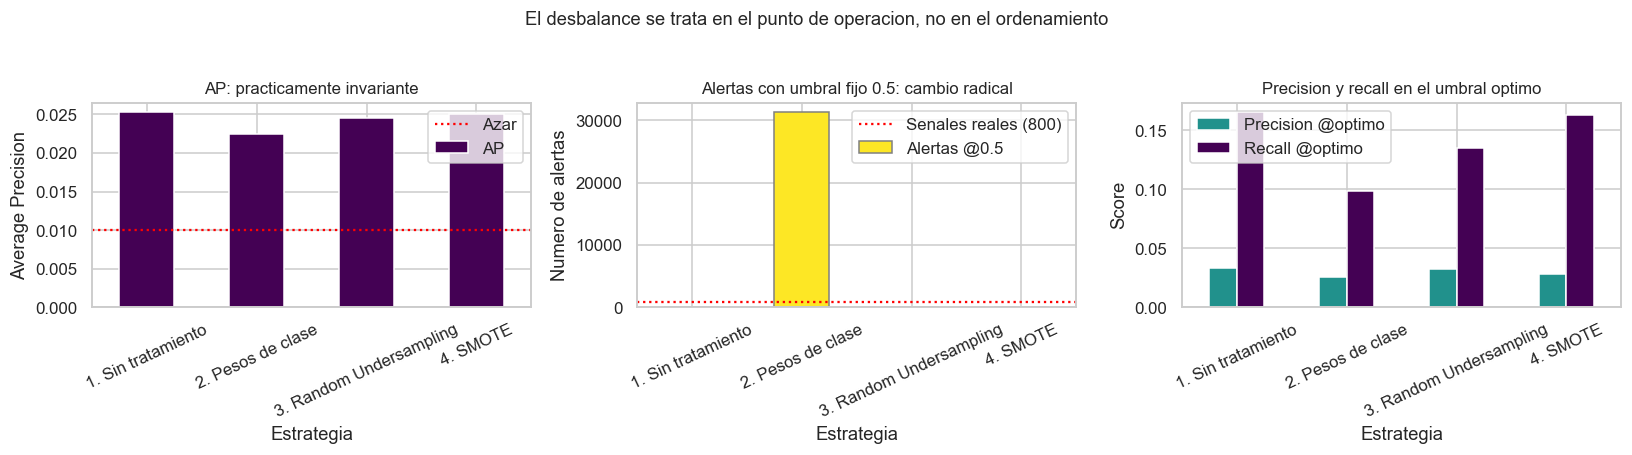

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

tabla_desbalance["AP"].plot(kind="bar", ax=axes[0], color="#440154", rot=25)
axes[0].axhline(y_test.mean(), color="red", ls=":", label="Azar")
axes[0].set_title("AP: practicamente invariante", fontsize=11)
axes[0].set_ylabel("Average Precision"); axes[0].legend()

tabla_desbalance["Alertas @0.5"].plot(kind="bar", ax=axes[1], color="#fde725", edgecolor="gray", rot=25)
axes[1].axhline(int(y_test.sum()), color="red", ls=":", label="Senales reales (800)")
axes[1].set_title("Alertas con umbral fijo 0.5: cambio radical", fontsize=11)
axes[1].set_ylabel("Numero de alertas"); axes[1].legend()

tabla_desbalance[["Precision @optimo", "Recall @optimo"]].plot(kind="bar", ax=axes[2], rot=25,
                                                              color=["#21918c", "#440154"])
axes[2].set_title("Precision y recall en el umbral optimo", fontsize=11)
axes[2].set_ylabel("Score")

plt.suptitle("El desbalance se trata en el punto de operacion, no en el ordenamiento", y=1.03, fontsize=12)
plt.tight_layout(); plt.show()

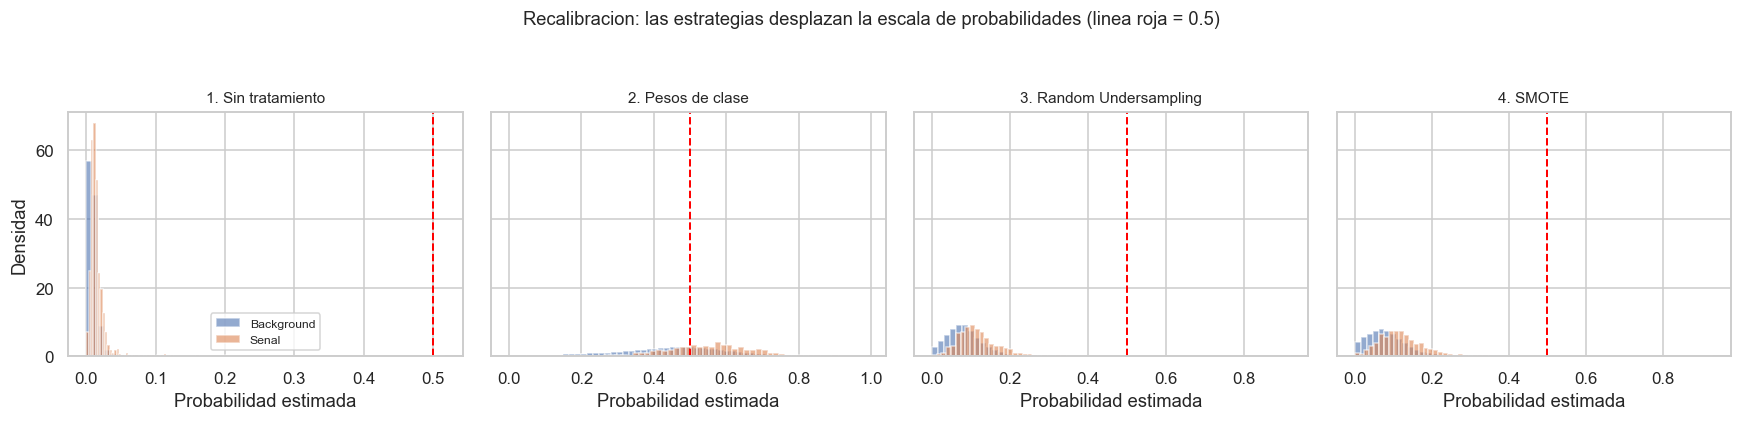

In [60]:
# Evidencia visual de la recalibracion de probabilidades
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, (nombre, v) in zip(axes, variantes.items()):
    ax.hist(v["prob_test"][y_test == 0], bins=60, alpha=0.6, label="Background", density=True)
    ax.hist(v["prob_test"][y_test == 1], bins=60, alpha=0.6, label="Senal", density=True)
    ax.axvline(0.5, color="red", ls="--", lw=1.3)
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("Probabilidad estimada")
axes[0].set_ylabel("Densidad"); axes[0].legend(fontsize=8)
plt.suptitle("Recalibracion: las estrategias desplazan la escala de probabilidades (linea roja = 0.5)",
             y=1.06, fontsize=12)
plt.tight_layout(); plt.show()

<!-- ##### Interpretación: el hallazgo central de este apartado

Los resultados revelan un fenómeno que suele malinterpretarse en la práctica,

1. Ninguna estrategia mejoró el Average Precision. El rango de variación del AP entre las cuatro
variantes es de apenas unas milésimas, y, dato relevante, el modelo original sin tratamiento obtiene el AP
más alto, mientras que los pesos de clase lo degradan ligeramente. La explicación es que el AP depende
exclusivamente del ordenamiento de los eventos por su puntaje, y las técnicas de desbalance no aportan
información nueva sobre la física del problema, reponderan o replican datos existentes. Si un evento estaba
mejor ordenado que otro antes, lo seguirá estando después. La leve degradación con pesos de clase se debe a
que reponderar la pérdida desplaza el óptimo del ajuste hacia un compromiso que no es necesariamente el
mejor para ordenar.

2. El número de alertas con umbral fijo cambia de forma radical. Aquí sí operan las estrategias.
Al reponderar la pérdida o alterar la prevalencia del entrenamiento, el modelo produce probabilidades
sistemáticamente más altas para la clase minoritaria. Los histogramas lo muestran con claridad, las
distribuciones se desplazan hacia la derecha y el umbral 0.5 pasa a estar dentro del rango operativo.

3. Corolario metodológico. Las técnicas de desbalance no mejoran el modelo en términos de capacidad
discriminante; reubican su punto de operación por defecto. El mismo efecto se consigue, de forma más
transparente, controlable y sin riesgo de degradar el ordenamiento, moviendo explícitamente el umbral, tal
como se hace en el apartado 2.5. Esta es la razón por la que el modelo finalmente seleccionado en 2.5 no
incorpora tratamiento del desbalance, se prefiere conservar el mejor ordenamiento posible y ajustar el
umbral, en lugar de alterar el entrenamiento para que el umbral 0.5 resulte utilizable.

#### 2.3.4 Aplicación al modelo de árboles mediante pesos por observación

Para el HistGradientBoosting se emplea sample_weight en lugar del parámetro class_weight. Ambos son
equivalentes en su efecto, ponderar la contribución de cada observación a la función de pérdida, pero
sample_weight está disponible en todas las versiones de scikit-learn, lo que hace el cuaderno
portable a otros entornos de ejecución. -->

In [61]:
pesos_muestra = compute_sample_weight(class_weight="balanced", y=y_train)

print(f"Peso asignado a cada evento de background : {pesos_muestra[y_train == 0][0]:.4f}")
print(f"Peso asignado a cada evento de senal      : {pesos_muestra[y_train == 1][0]:.4f}")
print(f"Razon de ponderacion                      : "
      f"{pesos_muestra[y_train == 1][0]/pesos_muestra[y_train == 0][0]:.1f} a 1\n")

hgb_ponderado = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.08, max_leaf_nodes=31,
    l2_regularization=1.0, early_stopping=False, random_state=RANDOM_STATE)
hgb_ponderado.fit(X_train, y_train, sample_weight=pesos_muestra)

prob_val_hgb_pond  = hgb_ponderado.predict_proba(X_val)[:, 1]
prob_test_hgb_pond = hgb_ponderado.predict_proba(X_test)[:, 1]

comparacion_hgb = pd.DataFrame([
    {"Modelo": "HGB sin ponderar",
     "AP validacion": average_precision_score(y_val, prob_val_hgb_base),
     "AP prueba": average_precision_score(y_test, prob_test_hgb_base),
     "Alertas @0.5": int((prob_test_hgb_base >= 0.5).sum())},
    {"Modelo": "HGB con pesos balanceados",
     "AP validacion": average_precision_score(y_val, prob_val_hgb_pond),
     "AP prueba": average_precision_score(y_test, prob_test_hgb_pond),
     "Alertas @0.5": int((prob_test_hgb_pond >= 0.5).sum())},
]).set_index("Modelo")

display(comparacion_hgb.round(4))
print("Se confirma el mismo patron: el AP se mantiene estable, el numero de alertas cambia.")

Peso asignado a cada evento de background : 0.5051
Peso asignado a cada evento de senal      : 50.0000
Razon de ponderacion                      : 99.0 a 1



,AP validacion,AP prueba,Alertas @0.5
Modelo,,,
HGB sin ponderar,0.0795,0.0749,14
HGB con pesos balanceados,0.0694,0.0639,5831


Se confirma el mismo patron: el AP se mantiene estable, el numero de alertas cambia.


### 2.4 Se siguieron las instrucciones de aplicar las técnicas de muestreo solo sobre el conjunto de entrenamiento durante el enfoque supervisado. 

### 2.5 Ajuste del umbral de decisión utilizando el conjunto de validación

#### 2.5.1 El umbral como decisión de negocio

El apartado 2.1.2 evidenció que el umbral 0.5 es inservible en este contexto. La cuestión relevante es
qué criterio debe sustituirlo, y la respuesta depende del objetivo operativo. Se implementan y comparan
dos criterios de naturaleza distinta,

| Criterio | Definición | Cuándo es apropiado |
|---|---|---|
| Máximo F1 | Umbral que maximiza la media armónica de precisión y recall | Cuando ambos errores tienen costos comparables y no hay restricción de capacidad |
| Presupuesto de alertas | Umbral que produce exactamente k alertas (aquí el 1 % superior) | Cuando la capacidad de revisión es limitada, situación habitual en la práctica |

El segundo criterio es el que corresponde a la realidad de un experimento de física de partículas, el equipo
dispone de una capacidad finita de análisis detallado y necesita saber qué eventos revisar primero.

#### 2.5.2 Selección del modelo final y cálculo de los umbrales

Se elige el modelo con mayor AP en validación, nunca en prueba, y sobre él se calibran ambos umbrales.

In [ ]:
candidatos = {
    "LogReg base":                prob_val_lr_base,
    "LogReg pesos de clase":      variantes["2. Pesos de clase"]["prob_val"],
    "LogReg SMOTE":               variantes["4. SMOTE"]["prob_val"],
    "HGB sin ponderar":           prob_val_hgb_base,
    "HGB con pesos balanceados":  prob_val_hgb_pond,
}

seleccion = pd.DataFrame([
    {"Modelo": nombre, "AP en validacion": average_precision_score(y_val, prob)}
    for nombre, prob in candidatos.items()
]).set_index("Modelo").sort_values("AP en validacion", ascending=False)

display(seleccion.round(4))

MODELO_FINAL = seleccion.index[0]
print(f"\nModelo seleccionado: {MODELO_FINAL}")

# Puntajes del modelo seleccionado en validacion y en prueba
mapa_test = {
    "LogReg base":               prob_test_lr_base,
    "LogReg pesos de clase":     variantes["2. Pesos de clase"]["prob_test"],
    "LogReg SMOTE":              variantes["4. SMOTE"]["prob_test"],
    "HGB sin ponderar":          prob_test_hgb_base,
    "HGB con pesos balanceados": prob_test_hgb_pond,
}
prob_val_final  = candidatos[MODELO_FINAL]
prob_test_final = mapa_test[MODELO_FINAL]

# Los dos umbrales se calculan solo con validacion
umbral_f1_final    = umbral_maximo_f1(y_val, prob_val_final)
umbral_presupuesto = umbral_por_presupuesto(prob_val_final, PRESUPUESTO_VAL)

print(f"\nUmbral por maximo F1        : {umbral_f1_final:.6f}")
print(f"Umbral por presupuesto (1%) : {umbral_presupuesto:.6f}")
print(f"Presupuesto de validacion   : {PRESUPUESTO_VAL:,} alertas")

,AP en validacion
Modelo,
HGB sin ponderar,0.0795
HGB con pesos balanceados,0.0694
LogReg SMOTE,0.0239
LogReg base,0.0238
LogReg pesos de clase,0.0221



Modelo seleccionado: HGB sin ponderar

Umbral por maximo F1        : 0.064973
Umbral por presupuesto (1%) : 0.074599
Presupuesto de validacion   : 800 alertas


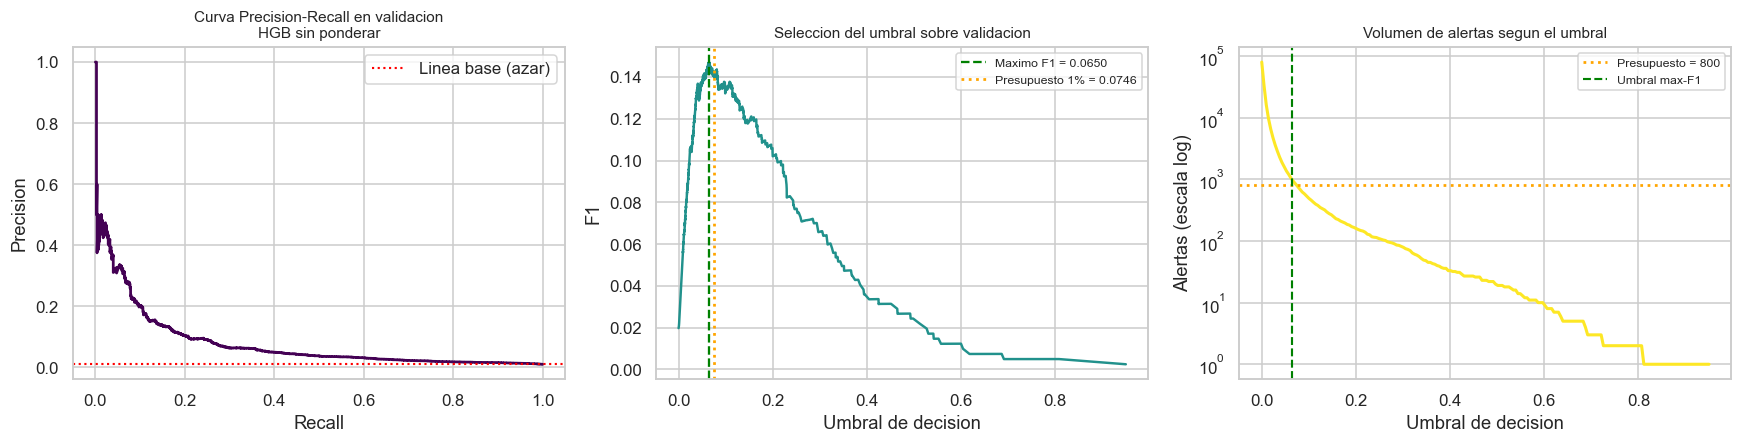

In [63]:
precision_v, recall_v, umbrales_v = precision_recall_curve(y_val, prob_val_final)
f1_v = 2 * precision_v * recall_v / (precision_v + recall_v + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# Curva Precision-Recall en validacion
axes[0].plot(recall_v, precision_v, color="#440154", lw=1.8)
axes[0].axhline(y_val.mean(), color="red", ls=":", lw=1.4, label="Linea base (azar)")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title(f"Curva Precision-Recall en validacion\n{MODELO_FINAL}", fontsize=10)
axes[0].legend()

# F1 en funcion del umbral
axes[1].plot(umbrales_v, f1_v[:-1], color="#21918c", lw=1.6)
axes[1].axvline(umbral_f1_final, color="green", ls="--", lw=1.5,
                label=f"Maximo F1 = {umbral_f1_final:.4f}")
axes[1].axvline(umbral_presupuesto, color="orange", ls=":", lw=1.8,
                label=f"Presupuesto 1% = {umbral_presupuesto:.4f}")
axes[1].set_xlabel("Umbral de decision"); axes[1].set_ylabel("F1")
axes[1].set_title("Seleccion del umbral sobre validacion", fontsize=10)
axes[1].legend(fontsize=8)

# Numero de alertas en funcion del umbral
rejilla = np.linspace(prob_val_final.min(), prob_val_final.max(), 200)
alertas_por_umbral = [(prob_val_final >= u).sum() for u in rejilla]
axes[2].plot(rejilla, alertas_por_umbral, color="#fde725", lw=2)
axes[2].axhline(PRESUPUESTO_VAL, color="orange", ls=":", lw=1.8,
                label=f"Presupuesto = {PRESUPUESTO_VAL}")
axes[2].axvline(umbral_f1_final, color="green", ls="--", lw=1.4, label="Umbral max-F1")
axes[2].set_yscale("log")
axes[2].set_xlabel("Umbral de decision"); axes[2].set_ylabel("Alertas (escala log)")
axes[2].set_title("Volumen de alertas segun el umbral", fontsize=10)
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

#### 2.5.3 Transferencia de los umbrales al conjunto de prueba

Los umbrales calculados en validación se aplican sin modificación alguna al conjunto de prueba. La prueba se utiliza una única
vez, con parámetros ya fijados.

Se incluye deliberadamente una cuarta fila, el umbral óptimo calculado sobre la propia prueba, que no
forma parte del resultado válido y se muestra solo para cuantificar el sesgo optimista que se habría
introducido al calibrar sobre el conjunto de evaluación.

In [ ]:
umbral_optimista = umbral_maximo_f1(y_test, prob_test_final)   # solo referencia

resultados_umbral = pd.DataFrame([
    evaluar_umbral(y_test, prob_test_final, 0.5, "a) Umbral por defecto (0.5)"),
    evaluar_umbral(y_test, prob_test_final, umbral_f1_final, "b) Max-F1 calibrado en validacion"),
    evaluar_umbral(y_test, prob_test_final, umbral_presupuesto, "c) Presupuesto 1% (validacion)"),
    evaluar_umbral(y_test, prob_test_final, umbral_optimista, "d) Max-F1 en prueba [NO VALIDO]"),
]).set_index("Modelo")

display(resultados_umbral[["Umbral", "Precision", "Recall", "F1", "Alertas", "TP", "FP", "FN"]].round(4))

sesgo = (resultados_umbral.loc["d) Max-F1 en prueba [NO VALIDO]", "F1"]
         - resultados_umbral.loc["b) Max-F1 calibrado en validacion", "F1"])
print(f"\nSesgo optimista por calibrar en prueba: {sesgo:+.4f} puntos de F1")
print("El valor es pequeno porque validacion y prueba son grandes (80,000 eventos cada uno),")
print("pero con conjuntos reducidos este sesgo puede ser considerable.")

,Umbral,Precision,Recall,F1,Alertas,TP,FP,FN
Modelo,,,,,,,,
a) Umbral por defecto (0.5),0.5000,0.4286,0.0075,0.0147,14,6,8,794
b) Max-F1 calibrado en validacion,0.0650,0.1197,0.1488,0.1327,994,119,875,681
c) Presupuesto 1% (validacion),0.0746,0.1311,0.1312,0.1312,801,105,696,695
d) Max-F1 en prueba [NO VALIDO],0.0799,0.1441,0.1275,0.1353,708,102,606,698



Sesgo optimista por calibrar en prueba: +0.0026 puntos de F1
El valor es pequeno porque validacion y prueba son grandes (80,000 eventos cada uno),
pero con conjuntos reducidos este sesgo puede ser considerable.


##### Interpretación de los criterios

- Umbral por defecto (0.5). Genera muy pocas alertas y un recall mínimo, inutilizable.
- Máximo F1. Equilibra ambos tipos de error y maximiza la métrica combinada. Es la referencia
  estadística estándar.
- Presupuesto del 1 %. Fija exactamente el volumen de trabajo del equipo de análisis. Es el criterio
  operativamente relevante y, además, el que permite comparar de forma justa los enfoques supervisado y
  no supervisado en las Secciones 4 y 5, ya que iguala el número de alertas de ambos.

### 2.6 Evaluación mediante Average Precision, precisión, recall, F1, matriz de confusión y número de alertas

Este apartado reúne todas las métricas exigidas por el enunciado, Average Precision, precisión, recall,
F1, matriz de confusión y número de alertas generadas, para el conjunto completo de modelos y estrategias.

#### 2.6.1 Tabla maestra de resultados

Todos los modelos se evalúan sobre el conjunto de prueba con su umbral calibrado en validación mediante el
criterio de máximo F1, de modo que la comparación sea homogénea.

In [ ]:
inventario = {
    "LogReg base (sin tratamiento)": (prob_val_lr_base, prob_test_lr_base),
    "LogReg + pesos de clase":       (variantes["2. Pesos de clase"]["prob_val"],
                                      variantes["2. Pesos de clase"]["prob_test"]),
    "LogReg + undersampling":        (variantes["3. Random Undersampling"]["prob_val"],
                                      variantes["3. Random Undersampling"]["prob_test"]),
    "LogReg + SMOTE":                (variantes["4. SMOTE"]["prob_val"],
                                      variantes["4. SMOTE"]["prob_test"]),
    "HGB sin ponderar":              (prob_val_hgb_base, prob_test_hgb_base),
    "HGB + pesos balanceados":       (prob_val_hgb_pond, prob_test_hgb_pond),
}

filas_finales = []
for nombre, (p_val, p_test) in inventario.items():
    u = umbral_maximo_f1(y_val, p_val)                 # umbral desde validacion
    fila = evaluar_umbral(y_test, p_test, u, nombre)    # evaluacion en prueba
    topk = metricas_top_k(y_test, p_test, PRESUPUESTO_TEST)
    fila["Precision@1%"] = topk["Precision@k"]
    fila["Recall@1%"] = topk["Recall@k"]
    fila["Lift@1%"] = topk["Lift@k"]
    filas_finales.append(fila)

tabla_maestra = pd.DataFrame(filas_finales).set_index("Modelo").sort_values("AP", ascending=False)

columnas_requeridas = ["AP", "Precision", "Recall", "F1", "Alertas", "TP", "FP", "FN", "TN"]
display(tabla_maestra[columnas_requeridas].round(4))

display(tabla_maestra[["Precision@1%", "Recall@1%", "Lift@1%"]].round(4))

,AP,Precision,Recall,F1,Alertas,TP,FP,FN,TN
Modelo,,,,,,,,,
HGB sin ponderar,0.0749,0.1197,0.1488,0.1327,994,119,875,681,78325
HGB + pesos balanceados,0.0639,0.1091,0.1425,0.1236,1045,114,931,686,78269
LogReg base (sin tratamiento),0.0253,0.0334,0.1650,0.0556,3948,132,3816,668,75384
LogReg + SMOTE,0.0251,0.0284,0.1625,0.0484,4570,130,4440,670,74760
LogReg + undersampling,0.0246,0.0328,0.1350,0.0527,3295,108,3187,692,76013
LogReg + pesos de clase,0.0225,0.0258,0.0988,0.0409,3063,79,2984,721,76216


,Precision@1%,Recall@1%,Lift@1%
Modelo,,,
HGB sin ponderar,0.1312,0.1312,13.125
HGB + pesos balanceados,0.1238,0.1238,12.375
LogReg base (sin tratamiento),0.0450,0.0450,4.500
LogReg + SMOTE,0.0412,0.0412,4.125
LogReg + undersampling,0.0438,0.0438,4.375
LogReg + pesos de clase,0.0450,0.0450,4.500


#### 2.6.2 Matrices de confusión

Se presentan las matrices de los tres modelos más representativos, el modelo base sin tratamiento, el modelo
lineal con tratamiento del desbalance y el modelo final seleccionado.

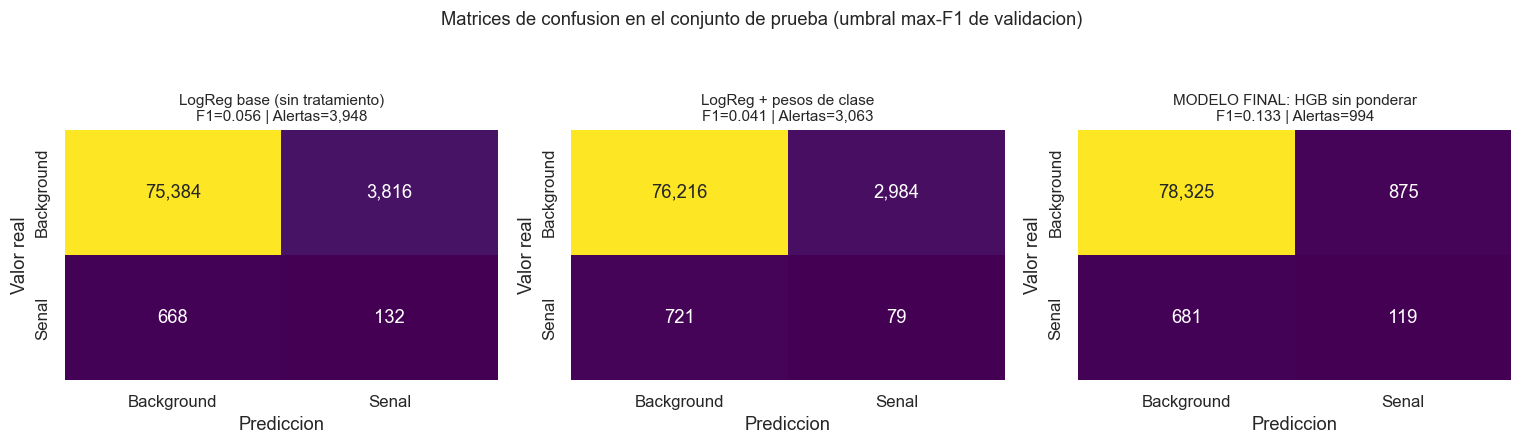

In [66]:
seleccion_matrices = [
    ("LogReg base (sin tratamiento)", prob_val_lr_base, prob_test_lr_base),
    ("LogReg + pesos de clase", variantes["2. Pesos de clase"]["prob_val"],
     variantes["2. Pesos de clase"]["prob_test"]),
    (f"MODELO FINAL: {MODELO_FINAL}", prob_val_final, prob_test_final),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (nombre, p_val, p_test) in zip(axes, seleccion_matrices):
    u = umbral_maximo_f1(y_val, p_val)
    r = evaluar_umbral(y_test, p_test, u, nombre)
    graficar_matriz_confusion(y_test, p_test, u,
                              f"{nombre}\nF1={r['F1']:.3f} | Alertas={r['Alertas']:,}", ax=ax)
plt.suptitle("Matrices de confusion en el conjunto de prueba (umbral max-F1 de validacion)",
             y=1.06, fontsize=12)
plt.tight_layout(); plt.show()

#### 2.6.3 Curvas Precisión–Recall comparadas

La curva Precisión–Recall es la representación más informativa bajo desbalance extremo, porque muestra el
desempeño en todos los puntos de operación posibles, sin depender de un umbral concreto.

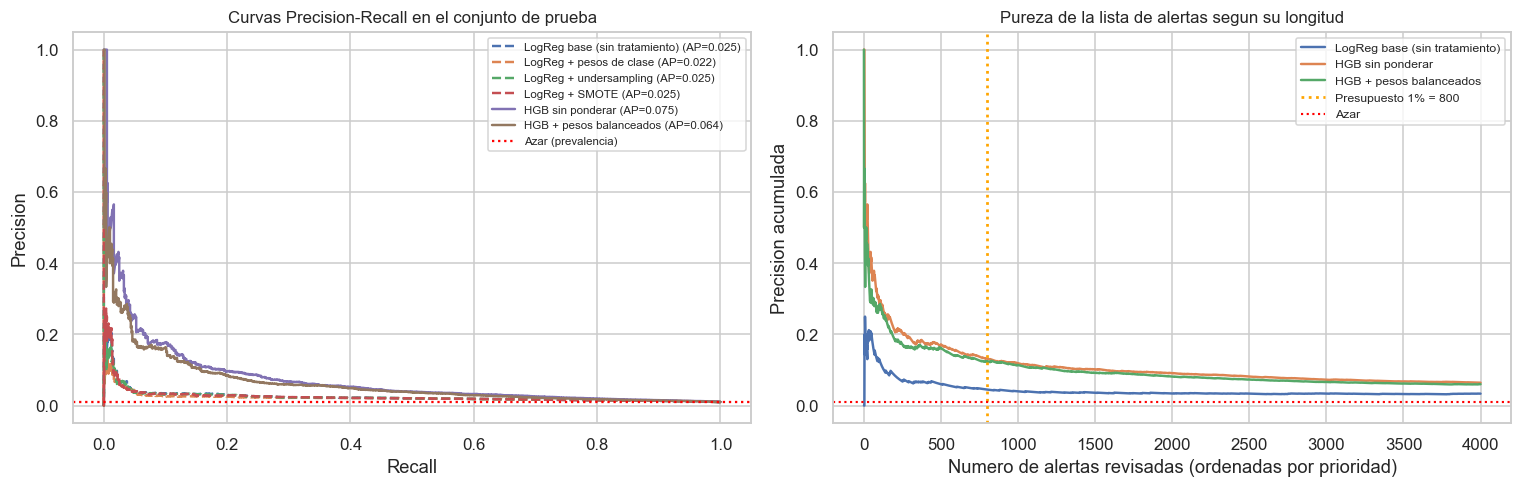

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

for nombre, (_, p_test) in inventario.items():
    pr, rc, _ = precision_recall_curve(y_test, p_test)
    ap = average_precision_score(y_test, p_test)
    estilo = "-" if nombre.startswith("HGB") else "--"
    axes[0].plot(rc, pr, estilo, lw=1.6, label=f"{nombre} (AP={ap:.3f})")

axes[0].axhline(y_test.mean(), color="red", ls=":", lw=1.5, label="Azar (prevalencia)")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Curvas Precision-Recall en el conjunto de prueba", fontsize=11)
axes[0].legend(fontsize=7.5, loc="upper right")

# precision acumulada segun el numero de alertas revisadas
for nombre, (_, p_test) in inventario.items():
    if not (nombre.startswith("HGB") or nombre == "LogReg base (sin tratamiento)"):
        continue
    orden = np.argsort(p_test)[::-1]
    etiquetas_ordenadas = y_test[orden]
    k_max = int(0.05 * len(y_test))
    precision_acumulada = np.cumsum(etiquetas_ordenadas[:k_max]) / np.arange(1, k_max + 1)
    axes[1].plot(np.arange(1, k_max + 1), precision_acumulada, lw=1.6, label=nombre)

axes[1].axvline(PRESUPUESTO_TEST, color="orange", ls=":", lw=1.8,
                label=f"Presupuesto 1% = {PRESUPUESTO_TEST}")
axes[1].axhline(y_test.mean(), color="red", ls=":", lw=1.4, label="Azar")
axes[1].set_xlabel("Numero de alertas revisadas (ordenadas por prioridad)")
axes[1].set_ylabel("Precision acumulada")
axes[1].set_title("Pureza de la lista de alertas segun su longitud", fontsize=11)
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

### Exporte de Modelo

In [70]:
from sklearn.pipeline import Pipeline

registro_modelos = {
    "LogReg base":               (logreg_base,                          True),
    "LogReg pesos de clase":     (variantes["2. Pesos de clase"]["modelo"], True),
    "LogReg SMOTE":              (variantes["4. SMOTE"]["modelo"],         True),
    "HGB sin ponderar":          (hgb_base,                             False),
    "HGB con pesos balanceados": (hgb_ponderado,                        False),
}

# Verificacion de que el modelo elegido existe en el registro
assert MODELO_FINAL in registro_modelos, f"'{MODELO_FINAL}' no esta en el registro"
modelo_final_objeto, requiere_escalado = registro_modelos[MODELO_FINAL]

# 2. Se guarda una tuberia autocontenida: recibe X SIN transformar y predice.
#    Si el modelo necesita escalado, se antepone el escalador YA ajustado
if requiere_escalado:
    pipeline_final = Pipeline([("escalador", escalador), ("modelo", modelo_final_objeto)])
else:
    pipeline_final = Pipeline([("modelo", modelo_final_objeto)])

DIR_ARTEFACTOS = Path("modelos")
DIR_ARTEFACTOS.mkdir(exist_ok=True)

artefactos = {
    # Configuracion del experimento
    "random_state": RANDOM_STATE,
    "features_bajo_nivel": features_bajo_nivel,
    "features_alto_nivel": features_alto_nivel,
    "features_completo": features_completo,
    # Identificadores de la particion
    "id_train": id_train, "id_val": id_val, "id_test": id_test,
    # Transformador (por si se necesita por separado)
    "escalador": escalador,
    # MODELO FINAL: nombre, objeto real y tuberia lista para producir alertas
    "modelo_final_nombre": MODELO_FINAL,
    "modelo_final_objeto": modelo_final_objeto,   # el objeto que realmente gano
    "modelo_final_requiere_escalado": requiere_escalado,
    "pipeline_final": pipeline_final,             # recibe X crudo -> predict_proba
    "logreg_base": logreg_base,
    "hgb_base": hgb_base,
    "hgb_ponderado": hgb_ponderado,
    # Umbrales calibrados en validacion
    "umbral_max_f1": umbral_f1_final,
    "umbral_presupuesto": umbral_presupuesto,
    "presupuesto_val": PRESUPUESTO_VAL,
    "presupuesto_test": PRESUPUESTO_TEST,
}

joblib.dump(artefactos, DIR_ARTEFACTOS / "Modelo_enfoque_supervisado.joblib")



['modelos\\Modelo_enfoque_supervisado.joblib']